In [1]:
##LIBRERIAS###
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
def leer_columnas(path_archivo):
    columnas = []

    with open(Path(path_archivo), "r", encoding="latin-1", errors="ignore") as f:
        next(f)  # <<< aquí saltamos la primera línea siempre
        for linea in f:
            partes = linea.strip().replace(",", ".").split()
            
            try:
                fila = [float(x) for x in partes]
                
                if not columnas:
                    columnas = [[] for _ in range(len(fila))]
           
                for i, val in enumerate(fila):
                    columnas[i].append(val)
            except ValueError:
                # Si no puede convertir, simplemente ignora esa fila
                continue

    return np.array(columnas)


In [12]:
def plot_patron(x_principal, y_principal, x_segundario, y_segundario, titulo,
                mins_principal, maxs_principal, mins_seg=None, maxs_seg=None,
                dx_error=0.0005, dy_error=0.01):
    # Colores base
    color_principal = "#51D63F"   # Verde (doble rendija)
    color_segundario = "#D6259B"  # Fucsia (rendija simple)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel('Tetha (rad)')
    ax.set_ylabel('Intensidad (mV)')
    ax.grid(True, alpha=0.4)
    
    # === GRAFICA PRINCIPAL (errorbar completo) ===
    ax.errorbar(
        x_principal, y_principal,
        xerr=dx_error, yerr=dy_error,
        fmt='-', color=color_principal, ecolor='gray', elinewidth=0.8, capsize=2,
        label='Doble rendija'
    )
    
    # === MINI-GRAFICA (errorbar completo también) ===
    ax_inset = inset_axes(ax, width="30%", height="30%", loc='upper right', borderpad=2)
    ax_inset.errorbar(
        x_segundario, y_segundario,
        xerr=dx_error, yerr=dy_error,
        fmt='-', color=color_segundario, ecolor='gray', elinewidth=0.8, capsize=2
    )
    ax_inset.set_title('Rendija sencilla', fontsize=9)
    ax_inset.tick_params(axis='both', labelsize=8)
    ax_inset.grid(True, alpha=0.4)

    # === LEYENDA: incluir min/max de ambas ===
    # === Unificación de leyenda: valores de máximos y mínimos (doble + simple) ===
    # Se añade una sola vez a la gráfica grande
    legend_texts = []

    # Doble rendija
    for (xm, ym) in mins_principal:
        legend_texts.append(f"Mín Doble:  x = {xm:.3f} ± {dx_error:.3f} cm,  y = {ym:.3f} ± {dy_error:.2f} mV")
    for (xM, yM) in maxs_principal:
        legend_texts.append(f"Máx Doble:  x = {xM:.3f} ± {dx_error:.3f} cm,  y = {yM:.3f} ± {dy_error:.2f} mV")

    # Rendija simple
    if mins_seg is not None:
        for (xm, ym) in mins_seg:
            legend_texts.append(f"Mín Simple:  x = {xm:.3f} ± {dx_error:.3f} cm,  y = {ym:.3f} ± {dy_error:.2f} mV")
    if maxs_seg is not None:
        for (xM, yM) in maxs_seg:
            legend_texts.append(f"Máx Simple:  x = {xM:.3f} ± {dx_error:.3f} cm,  y = {yM:.3f} ± {dy_error:.2f} mV")

    # Crear una sola entrada invisible que contenga todo el texto en la leyenda
    legend_label = "\n".join(legend_texts)
    ax.errorbar([], [], xerr=dx_error, yerr=dy_error, fmt='none',
                ecolor='lightgray', elinewidth=1.2, capsize=3,
                label=legend_label)


    # === Leyenda final ===
    ax.legend(loc='upper left', fontsize=8, frameon=True)
    plt.tight_layout()
    plt.show()



C:\Users\user\AppData\Local\Temp\ipykernel_10512\880731369.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


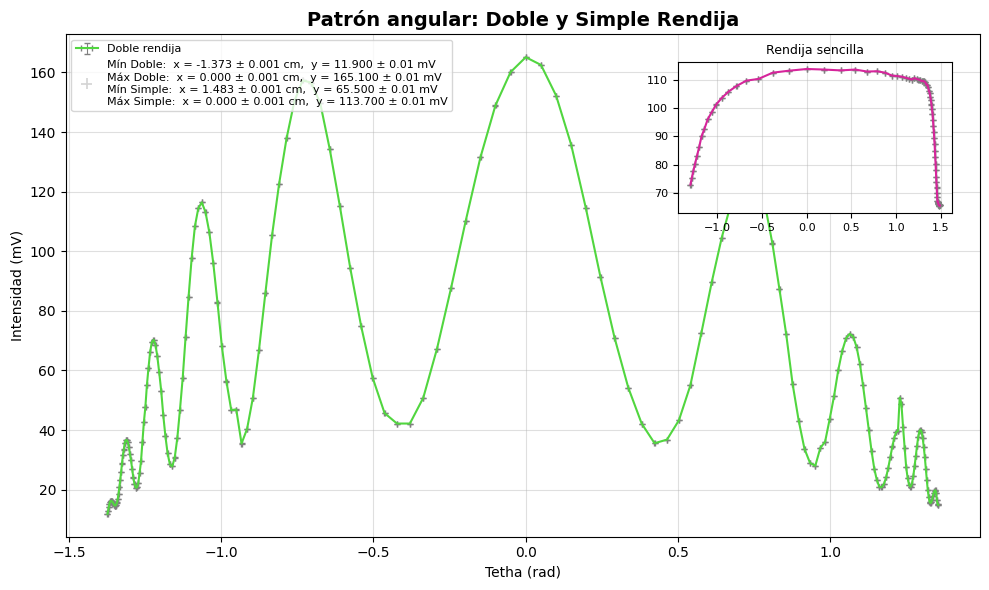

In [14]:
# --- Cargar datos ---
ondulatorio_doble = leer_columnas("Ondulatorio_Doble_Rendija.txt")
ondulatorio_simple = leer_columnas("Ondulatorio_Rendija_Sencilla.txt")

x_doble, y_doble = ondulatorio_doble[0], ondulatorio_doble[1]
x_simple, y_simple = ondulatorio_simple[0], ondulatorio_simple[1]

# --- Parámetro experimental ---
L = 100.0  # distancia pantalla-rendijas en cm (ajústalo con tu dato real)

# --- Máximos globales ---
idx_max_doble = np.argmax(y_doble)
idx_max_simple = np.argmax(y_simple)

# Centro en el máximo → x_central
x_central_doble = x_doble[idx_max_doble]
x_central_simple = x_simple[idx_max_simple]

# --- Convertir a ángulo y centrar en 0 ---
theta_doble = np.arctan((x_doble - x_central_doble) / L)
theta_simple = np.arctan((x_simple - x_central_simple) / L)

# --- Mínimos (en y, usando las mismas intensidades) ---
idx_min_doble = np.argmin(y_doble)
idx_min_simple = np.argmin(y_simple)

# Puntos en coordenadas angulares
mins_principal = [(theta_doble[idx_min_doble], y_doble[idx_min_doble])]
maxs_principal = [(0.0, y_doble[idx_max_doble])]  # por construcción el máximo está en θ = 0

mins_seg = [(theta_simple[idx_min_simple], y_simple[idx_min_simple])]
maxs_seg = [(0.0, y_simple[idx_max_simple])]      # idem para simple

# --- Llamar a la función de ploteo ---
plot_patron(theta_doble, y_doble,
            theta_simple, y_simple,
            "Patrón angular: Doble y Simple Rendija",
            mins_principal, maxs_principal,
            mins_seg, maxs_seg)
